<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day02_practice1_%EC%B5%9C%EC%86%8C%EC%A0%9C%EA%B3%B1_MSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지 설정
torch.manual_seed(42)

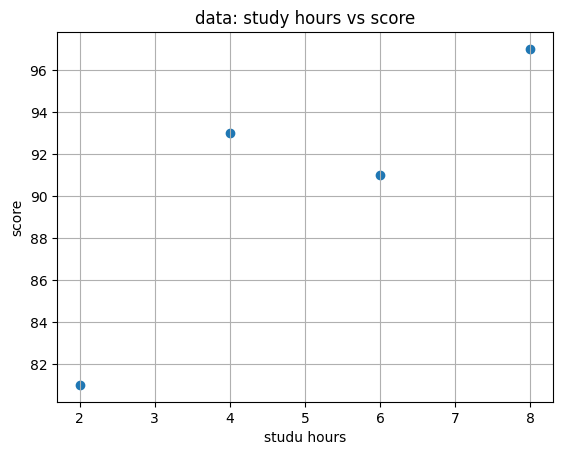

점 4개를 가장 잘 지나는 직선은?


In [5]:
# 셀 1. 교재 4장의 데이터 - 공부 시간과 성적
x = torch.tensor([2.0,4.0,6.0,8.0])     # 공부 시간
y = torch.tensor([81.0,93.0,91.0,97.0]) # 성적

plt.scatter(x,y)
plt.xlabel("studu hours"); plt.ylabel("score"); plt.grid(True)
plt.title("data: study hours vs score")
plt.savefig("plot1_data.png")
plt.show()
print("점 4개를 가장 잘 지나는 직선은?")\

# 우리가 찾는 것: y = ax + b 의 s(기울기)와 b(절편)
# '가장 훌륭한 에측선' -> 점들과의 거리가 가장 작은 직선

In [7]:
# 셀 2. 최소제곱법

# 최소제곱법 공식:
# a = Σ(x-x평균)(y-y평균) / Σ(x-x평균)²
# b = y퍙균 - (x평균 x a )

x_mean = x.mean()
y_mean = y.mean()

a = ((x-x_mean)*(y-y_mean)).sum() / ((x-x_mean)**2).sum()
b = y_mean - (x_mean*a)


print(f"x 평균: {x_mean:.1f}, y평균: {y_mean:.1f}")
print(f"계산된 기울기 a: {a:.1f}")
print(f"계산된 절편 b: {b:.1f}")

# y = 2.3x + 79

x 평균: 5.0, y평균: 90.5
계산된 기울기 a: 2.3
계산된 절편 b: 79.0


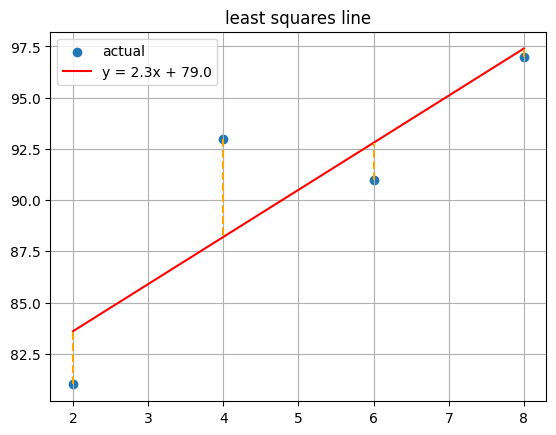

In [11]:
# 셀 3. 예측선 그리기 + 예측해 보기

pred = a * x + b        # 4명의 예측 성적

plt.scatter(x,y, label="actual")
plt.plot(x, pred, color="red", label=f"y = {a:.1f}x + {b:.1f}")

# 실제갑 yi와 예측값 pi의 차이(오차)를 세로선으로
for xi, yi, pi in zip(x,y,pred):
    plt.plot([xi,xi],[yi,pi], color="orange", ls="--") # Y축 범위: 실제값 yi에서 예측값 pi까지 (두 값 사이를 잇는 선)

plt.legend(); plt.grid(True); plt.title("least squares line")
plt.savefig("plot2_least_squares.png")
plt.show()

In [12]:
# 셀 4. 평균 제곱 오차(MSE) - '얼마나 틀렸냐'를 숫자 하나로
# MSE = (오차²)의 평균
# 오차 = 실제 - 예측
# 제곱: 부호 없애기
# 평균: 데이터 개수와 무관하게 비교 가능

def mse(y_true, y_pred):
  return ((y_true - y_pred) ** 2).mean()

print(f"최적선의 MSE: {mse(y,pred):.2f}")

# 일부러 나쁜 선과 비교해 보자
bad_pred = 3.0 * x + 70     # 아무렇게나 그은 선
print(f"나쁜 선 (y=3x+70)의 MSE: {mse(y, bad_pred):.2f}")

최적선의 MSE: 8.30
나쁜 선 (y=3x+70)의 MSE: 41.00
